In [1]:
#import statements
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import matplotlib.pyplot as plt
from torchinfo import summary
import numpy as np
from sklearn.neighbors import NearestNeighbors
from pytorch_lightning.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, r2_score
from sklearn.preprocessing import label_binarize
from pathlib import Path
from scipy import signal
import mne
from mne.preprocessing import ICA
from mne_icalabel.iclabel import iclabel_label_components
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from eeg_dataset import EEGSegmentDataset

/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pca_vals_raw = pd.read_parquet("model_data/matched_pca_vectors.parquet")
pca_vals = pd.DataFrame(
    np.stack(pca_vals_raw["vector"].to_numpy()),
    index=pca_vals_raw["subject"].astype(str),
)

In [3]:
ICA_DIR = "model_data/post_ica_19_channels" 

all_subjects = np.array(sorted(
    set(pca_vals.index) & {p.stem for p in Path(ICA_DIR).glob("*.parquet")}
))
print(f"ICA subjects available: {len(all_subjects)}")

shuffled = np.random.default_rng(42).permutation(all_subjects)
n_train = int(0.8 * len(shuffled))
train_subjects, test_subjects = shuffled[:n_train], shuffled[n_train:]
N_PCA, N_SEG, N_SAMPLES = 1, 1, 100
print(f"train: {len(train_subjects)}  test: {len(test_subjects)}  N_PCA={N_PCA}  N_SEG={N_SEG}  N_SAMPLES={N_SAMPLES}")

ICA subjects available: 1573
train: 1258  test: 315  N_PCA=1  N_SEG=1  N_SAMPLES=100


In [4]:
train_ds = EEGSegmentDataset(ICA_DIR, pca_vals,
                             n_pca_components=N_PCA, n_segments=N_SEG, n_samples=N_SAMPLES,
                             subject_ids=train_subjects)
test_ds  = EEGSegmentDataset(ICA_DIR, pca_vals,
                             n_pca_components=N_PCA, n_segments=N_SEG, n_samples=N_SAMPLES,
                             subject_ids=test_subjects,
                             target_mean=train_ds.target_mean,
                             target_std=train_ds.target_std)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)

  loaded 100/1258
  loaded 200/1258


KeyboardInterrupt: 

In [ ]:
class CatPool1d(nn.Module):
    """Concat avg and max pool, then project back to original channel count with a 1x1 conv."""
    def __init__(self, kernel_size, channels):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size)
        self.max = nn.MaxPool1d(kernel_size)
        self.proj = nn.Conv1d(channels * 2, channels, 1, bias=False)

    def forward(self, x):
        return self.proj(torch.cat([self.avg(x), self.max(x)], dim=1))


class CatAdaptivePool1d(nn.Module):
    """Concat adaptive avg and max pool, then project back to original channel count."""
    def __init__(self, channels):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool1d(1)
        self.max = nn.AdaptiveMaxPool1d(1)
        self.proj = nn.Conv1d(channels * 2, channels, 1, bias=False)

    def forward(self, x):
        return self.proj(torch.cat([self.avg(x), self.max(x)], dim=1))


class EEGTemporalCNN(nn.Module):
    def __init__(self, n_channels, n_outputs, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 128, 128, padding=64, bias=False),
            nn.BatchNorm1d(128), nn.GELU(), CatPool1d(4, 128), nn.Dropout(dropout),
            nn.Conv1d(128, 256, 16, padding=8, bias=False),
            nn.BatchNorm1d(256), nn.GELU(), CatPool1d(4, 256), nn.Dropout(dropout),
            nn.Conv1d(256, 256, 8, padding=4, bias=False),
            nn.BatchNorm1d(256), nn.GELU(),
            CatAdaptivePool1d(256), nn.Flatten(),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_outputs),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class EEGRegressor(pl.LightningModule):
    def __init__(self, n_channels, n_outputs, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()
        self.net = EEGTemporalCNN(n_channels, n_outputs)
        self.loss = nn.MSELoss()
        self._train_buf = []
        self._val_buf = []

    @staticmethod
    def _agg_r2(buf):
        preds = torch.cat([b[0] for b in buf]).numpy()
        targets = torch.cat([b[1] for b in buf]).numpy()
        subj = torch.cat([b[2] for b in buf]).numpy()
        agg_p, agg_t = [], []
        for s in np.unique(subj):
            m = subj == s
            agg_p.append(preds[m].mean(0))
            agg_t.append(targets[m].mean(0))
        agg_p, agg_t = np.stack(agg_p), np.stack(agg_t)
        if agg_p.shape[0] < 2:
            return np.full(agg_p.shape[1], np.nan)
        return r2_score(agg_t, agg_p, multioutput="raw_values")

    def training_step(self, batch, _):
        x, y, subj = batch
        pred = self.net(x)
        loss = self.loss(pred, y)
        self._train_buf.append((pred.detach().cpu(), y.detach().cpu(), subj.detach().cpu()))
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        r2 = self._agg_r2(self._train_buf)
        for i, v in enumerate(r2):
            self.log(f"train_r2_pc{i+1}", float(v))
        self.log("train_r2_mean", float(r2.mean()), prog_bar=True)
        self._train_buf.clear()

    def validation_step(self, batch, _):
        x, y, subj = batch
        pred = self.net(x)
        self._val_buf.append((pred.detach().cpu(), y.detach().cpu(), subj.detach().cpu()))
        self.log("val_loss", self.loss(pred, y), on_step=True, on_epoch=True, prog_bar=True)

    def on_validation_epoch_end(self):
        r2 = self._agg_r2(self._val_buf)
        for i, v in enumerate(r2):
            self.log(f"val_r2_pc{i+1}", float(v))
        self.log("val_r2_mean", float(r2.mean()), prog_bar=True)
        self._val_buf.clear()

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-2)

In [7]:
early_stop = EarlyStopping(monitor="val_r2_mean", mode="max", patience=20)

In [8]:
logger = TensorBoardLogger(save_dir="model_data", name="lightning_logs_ica_19_channels")
v = logger.version
ckpt_dir = Path("model_data/models_ica_19_channels")

In [9]:
best_ckpt = ModelCheckpoint(
    dirpath=ckpt_dir,
    monitor="val_r2_mean",
    mode="max",
    filename=f"best-v{v}",
    save_top_k=1,
    save_last=False,
)
last_ckpt = ModelCheckpoint(
    dirpath=ckpt_dir,
    monitor="epoch",
    mode="max",
    filename=f"last-v{v}",
    save_top_k=1,
)

In [10]:
model = EEGRegressor(n_channels=19, n_outputs=N_PCA)

In [11]:
trainer = pl.Trainer(
    max_epochs=50,
    accelerator="mps",
    devices=1,
    log_every_n_steps=1,
    callbacks=[best_ckpt, last_ckpt, early_stop],
    logger=logger,
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [12]:
trainer.fit(model, train_loader, test_loader)

/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/model_data/models_ica_19_channels exists and is not empty.

  | Name | Type           | Params | Mode  | FLOPs
--------------------------------------------------------
0 | net  | EEGTemporalCNN | 1.7 M  | train | 0    
1 | loss | MSELoss        | 0      | train | 0    
--------------------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M     Total params
6.756     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/william.wakefield/PycharmProjects/Mayo_EEG_FDG_project/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 492/492 [05:02<00:00,  1.63it/s, v_num=1, train_loss_step=0.176, val_loss_step=0.0527, val_loss_epoch=0.794, val_r2_mean=0.202, train_loss_epoch=0.180, train_r2_mean=0.915]   

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 492/492 [05:02<00:00,  1.62it/s, v_num=1, train_loss_step=0.176, val_loss_step=0.0527, val_loss_epoch=0.794, val_r2_mean=0.202, train_loss_epoch=0.180, train_r2_mean=0.915]


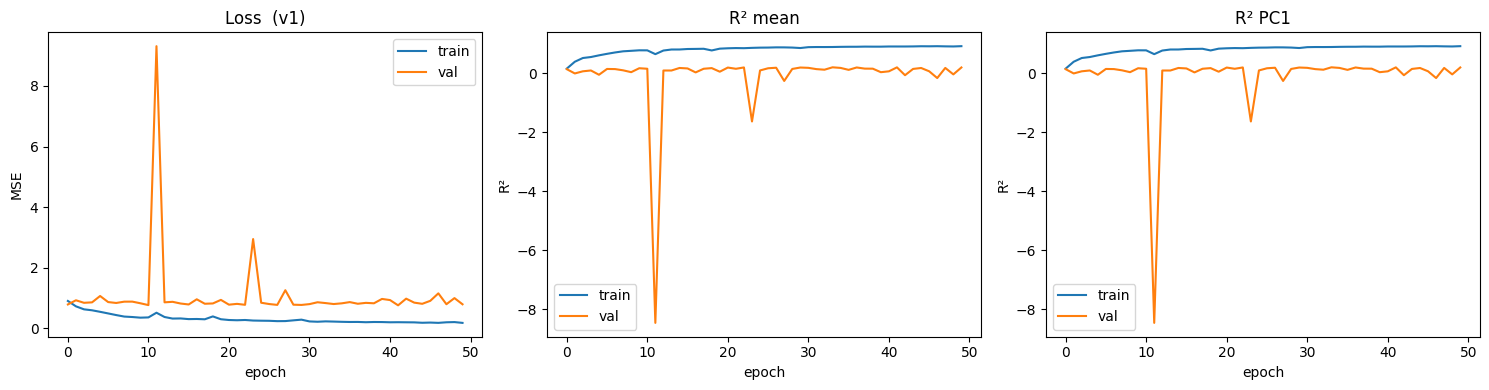

model_data/lightning_logs_ica_19_channels/version_1


In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

VERSION = 1

log_dir = Path(f"model_data/lightning_logs_ica_19_channels/version_{VERSION}")
ea = EventAccumulator(str(log_dir), size_guidance={"scalars": 0}); ea.Reload()
tags = ea.Tags()["scalars"]

def series(tag):
    return (list(range(len(ea.Scalars(tag)))), [e.value for e in ea.Scalars(tag)]) if tag in tags else ([], [])

n_pcs = sum(1 for t in tags if t.startswith("val_r2_pc"))
n_plots = 2 + n_pcs
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))

for tag, lab in [("train_loss_epoch", "train"), ("val_loss_epoch", "val")]:
    axes[0].plot(*series(tag), label=lab)
axes[0].set(xlabel="epoch", ylabel="MSE", title=f"Loss  (v{VERSION})"); axes[0].legend()

for tag, lab in [("train_r2_mean", "train"), ("val_r2_mean", "val")]:
    axes[1].plot(*series(tag), label=lab)
axes[1].set(xlabel="epoch", ylabel="R²", title="R² mean"); axes[1].legend()

for pc in range(1, n_pcs + 1):
    ax = axes[1 + pc]
    for tag, lab in [(f"train_r2_pc{pc}", "train"), (f"val_r2_pc{pc}", "val")]:
        ax.plot(*series(tag), label=lab)
    ax.set(xlabel="epoch", ylabel="R²", title=f"R² PC{pc}"); ax.legend()

plt.tight_layout(); plt.show()
print(log_dir)